# Etapa 0

Carregamento de bibliotecas

In [1]:
import cv2
import random
from pathlib import Path

# Etapa 1

Foram coletadas imagens em resolução 4032x3024. Para melhor performance, as imagens serão redimensionadas com o fator x0.25, utilizando Lanczos.

## Redimensionamento

In [2]:
from src.resize import resize_images

images_raw_dir = Path("./data/raw/")
images_processed_dir = Path("./data/processed")

resize_images(images_raw_dir, images_processed_dir, 0.25)

[Resize] IMG_0301.JPG: 4032×3024 → 1008×756
[Resize] IMG_0302.JPG: 4032×3024 → 1008×756
[Resize] IMG_0303.JPG: 4032×3024 → 1008×756
[Resize] IMG_0304.JPG: 4032×3024 → 1008×756
[Resize] IMG_0305.JPG: 4032×3024 → 1008×756
[Resize] IMG_0306.JPG: 4032×3024 → 1008×756
[Resize] IMG_0307.JPG: 4032×3024 → 1008×756
[Resize] IMG_0315.JPG: 4032×3024 → 1008×756


## Carregregamento das imagens

As imagens são embaralhadas antes de serem analisadas.

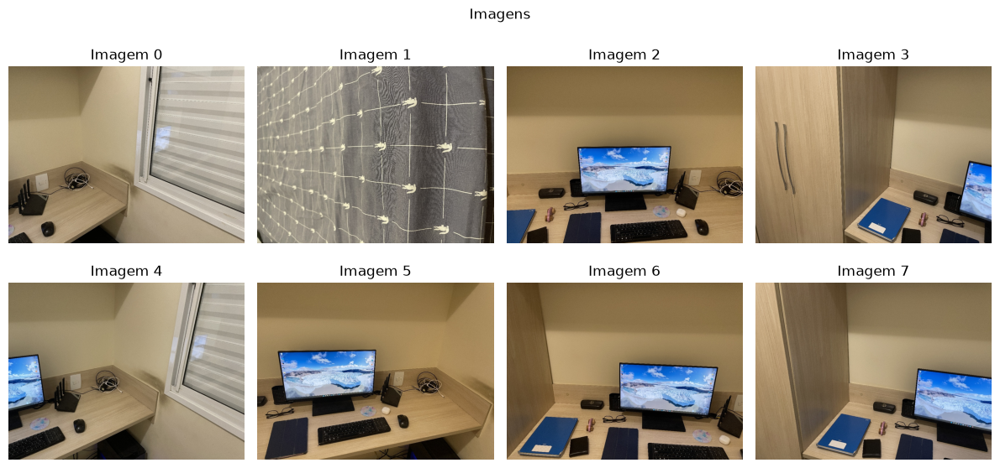

In [3]:
from src.visualization import plot_image_grid

images = []
for image_path in sorted(images_processed_dir.iterdir()):
    image = cv2.imread(image_path)
    images.append(image)

random.seed(2026)
random.shuffle(images)
plot_image_grid(images)

# Etapa 2

Detecção de keypoints com SIFT e ORB

[Features] Detector: SIFT
[Features]   Imagem 0: 535 keypoints, descritores (535, 128)
[Features]   Imagem 1: 3000 keypoints, descritores (3000, 128)
[Features]   Imagem 2: 1004 keypoints, descritores (1004, 128)
[Features]   Imagem 3: 476 keypoints, descritores (476, 128)
[Features]   Imagem 4: 754 keypoints, descritores (754, 128)
[Features]   Imagem 5: 1142 keypoints, descritores (1142, 128)
[Features]   Imagem 6: 899 keypoints, descritores (899, 128)
[Features]   Imagem 7: 820 keypoints, descritores (820, 128)


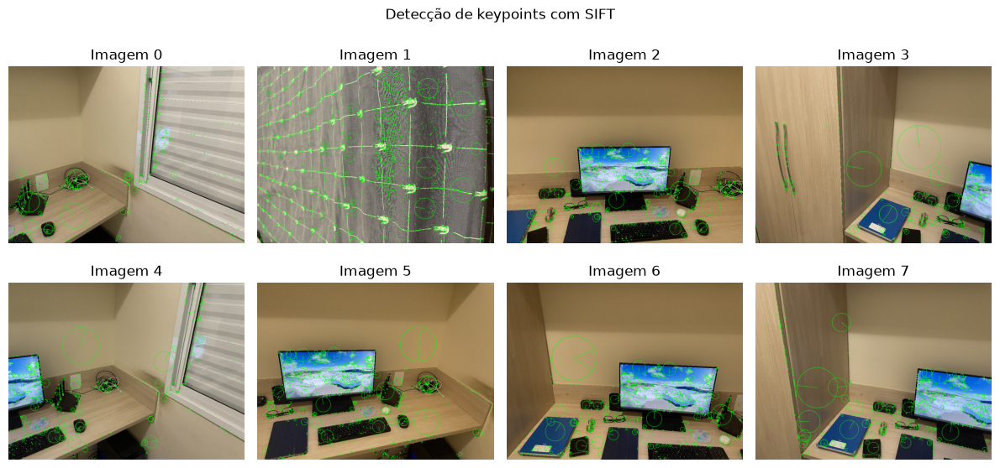

In [4]:
from src.features import draw_keypoints

images_sift = draw_keypoints(images, "sift") # array de dicts contendo { "image": (valor),  "keypoints": (valor), "descriptors": (valor) }

plot_image_grid([item["image"] for item in images_sift], "Detecção de keypoints com SIFT") # extrai "image" de cada item no array

[Features] Detector: ORB


[Features]   Imagem 0: 500 keypoints, descritores (500, 32)
[Features]   Imagem 1: 500 keypoints, descritores (500, 32)
[Features]   Imagem 2: 500 keypoints, descritores (500, 32)
[Features]   Imagem 3: 500 keypoints, descritores (500, 32)
[Features]   Imagem 4: 500 keypoints, descritores (500, 32)
[Features]   Imagem 5: 500 keypoints, descritores (500, 32)
[Features]   Imagem 6: 500 keypoints, descritores (500, 32)
[Features]   Imagem 7: 500 keypoints, descritores (500, 32)


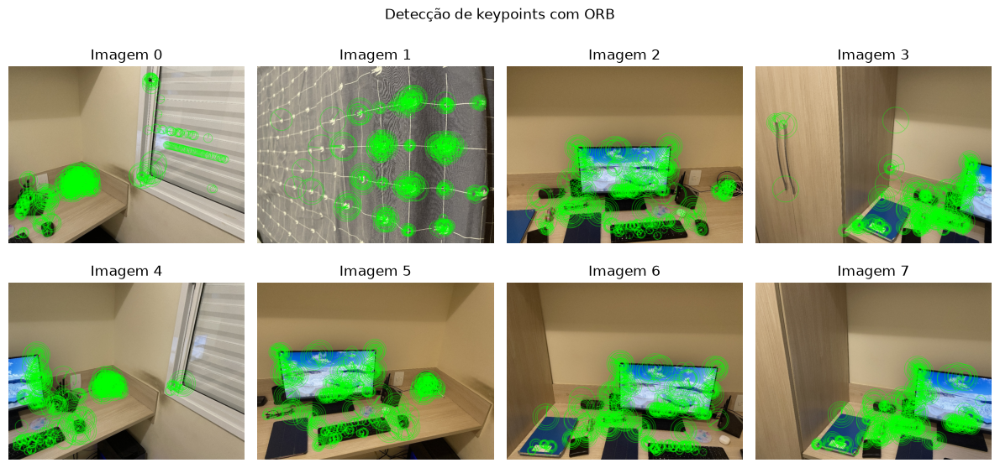

In [5]:
images_orb = draw_keypoints(images, "orb") # array de dicts contendo { "image": (valor),  "keypoints": (valor), "descriptors": (valor) }
plot_image_grid([item["image"] for item in images_orb], "Detecção de keypoints com ORB") # extrai "image" de cada item no array

# Etapa 3

Foi realizado casamento utilizando o Brute Force Matcher. Depois, é realizada a filtragem com o teste da razão de Lowe. Os resultados são guardados em uma matriz onde cada posição (i, j) possui a lista de casamentos entre a imagem i e imagem j.

In [6]:
keypoints = [item["keypoints"] for item in images_sift]
descriptors = [item["descriptors"] for item in images_sift]

In [7]:
from src.matching import match_all_images

RATIO_THRESHOLD = 0.8

matches_matrix, lowe_matrix = match_all_images(
    descriptors,
    method="sift",
    ratio=RATIO_THRESHOLD
)

print("Sem o teste de Lowe")
for i in range(len(matches_matrix)):
    for j in range(len(matches_matrix[i])):
        print(
            f"Imagem {i} <-> Imagem {j}: "
            f"{len(matches_matrix[i][j])} matches"
        )

print("Com o teste de Lowe")
for i in range(len(lowe_matrix)):
    for j in range(len(lowe_matrix[i])):
        print(
            f"Imagem {i} <-> Imagem {j}: "
            f"{len(lowe_matrix[i][j])} matches"
        )

Sem o teste de Lowe
Imagem 0 <-> Imagem 0: 0 matches
Imagem 0 <-> Imagem 1: 535 matches
Imagem 0 <-> Imagem 2: 535 matches
Imagem 0 <-> Imagem 3: 535 matches
Imagem 0 <-> Imagem 4: 535 matches
Imagem 0 <-> Imagem 5: 535 matches
Imagem 0 <-> Imagem 6: 535 matches
Imagem 0 <-> Imagem 7: 535 matches
Imagem 1 <-> Imagem 0: 3000 matches
Imagem 1 <-> Imagem 1: 0 matches
Imagem 1 <-> Imagem 2: 3000 matches
Imagem 1 <-> Imagem 3: 3000 matches
Imagem 1 <-> Imagem 4: 3000 matches
Imagem 1 <-> Imagem 5: 3000 matches
Imagem 1 <-> Imagem 6: 3000 matches
Imagem 1 <-> Imagem 7: 3000 matches
Imagem 2 <-> Imagem 0: 1004 matches
Imagem 2 <-> Imagem 1: 1004 matches
Imagem 2 <-> Imagem 2: 0 matches
Imagem 2 <-> Imagem 3: 1004 matches
Imagem 2 <-> Imagem 4: 1004 matches
Imagem 2 <-> Imagem 5: 1004 matches
Imagem 2 <-> Imagem 6: 1004 matches
Imagem 2 <-> Imagem 7: 1004 matches
Imagem 3 <-> Imagem 0: 476 matches
Imagem 3 <-> Imagem 1: 476 matches
Imagem 3 <-> Imagem 2: 476 matches
Imagem 3 <-> Imagem 3: 0 ma

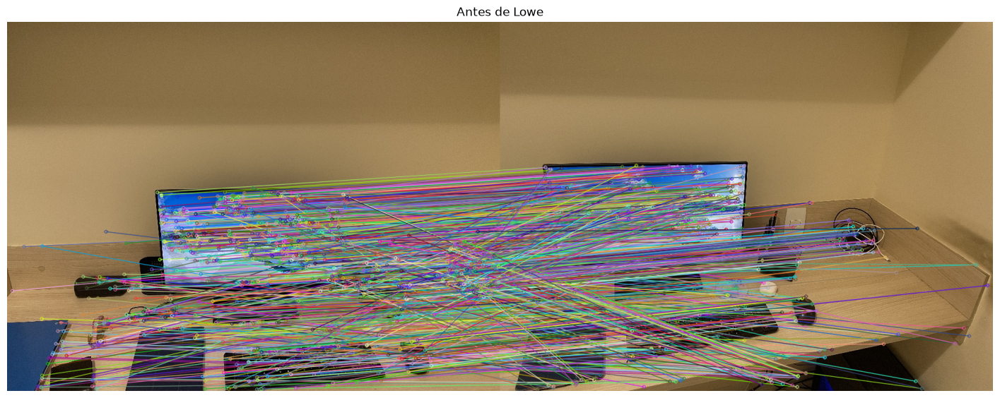

In [8]:
from src.visualization import plot_matches

i = 2
j = 5

plot_matches(images[i], # imagem sem os keypoints sobrepostos
            keypoints[i],
            images[j], 
            keypoints[j],
            matches_matrix[i][j], # matches associados ao par de imagens
            "Antes de Lowe")

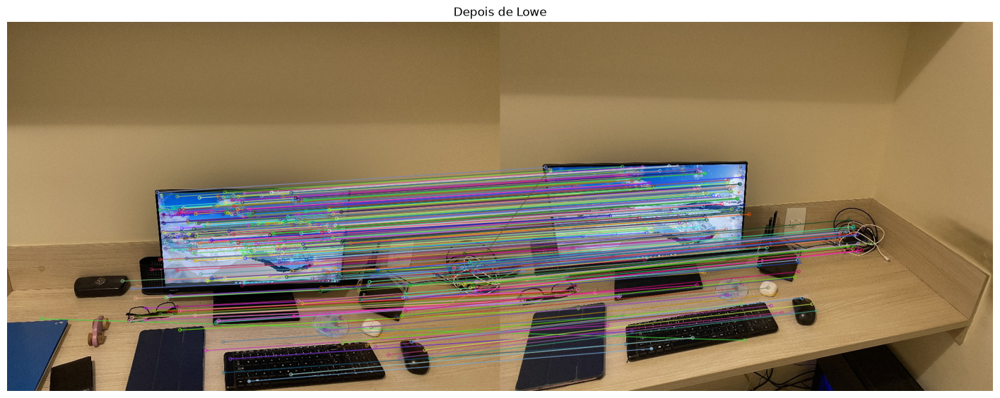

In [9]:
plot_matches(images[i], # imagem sem os keypoints sobrepostos
            keypoints[i], # keypoints
            images[j], 
            keypoints[j],
            lowe_matrix[i][j], # matches associados ao par de imagens, filtrados com teste da razão
            "Depois de Lowe")

# Etapa 4

Ordenação automática das imagens e eliminação da imagem intrusa.

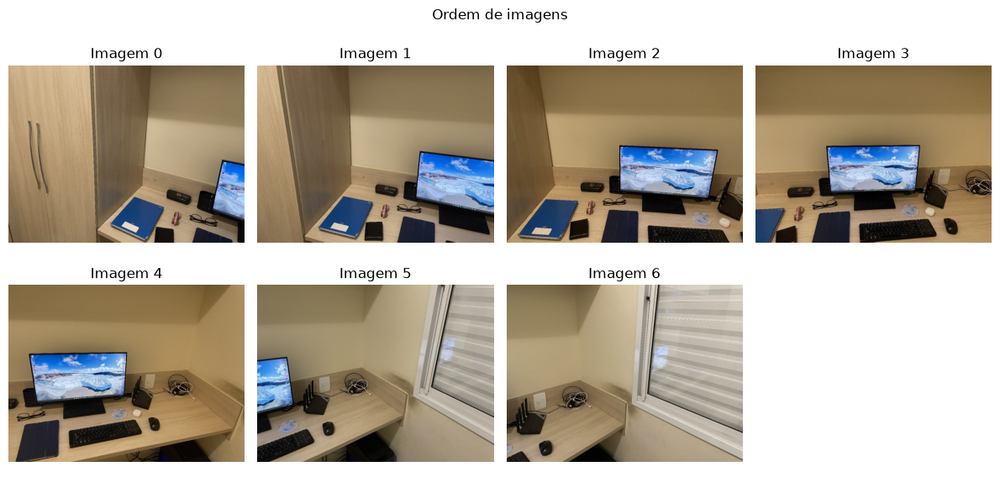

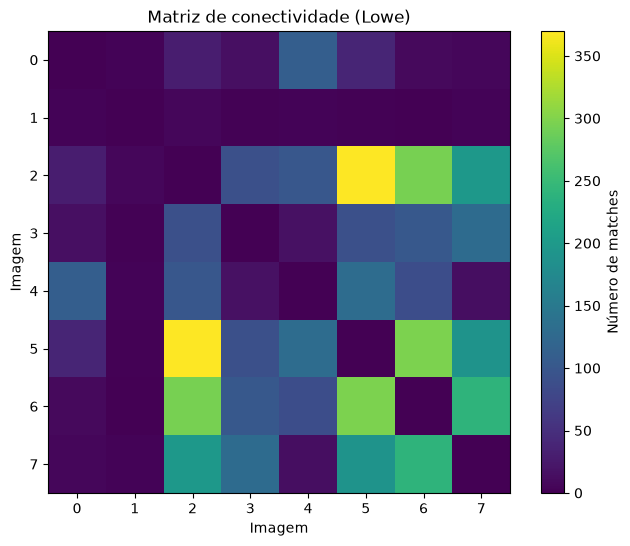

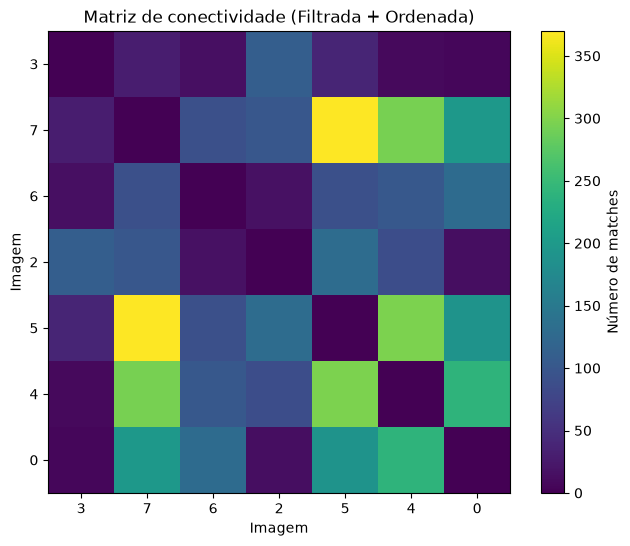

In [10]:
from src.ordering import infer_order
from src.visualization import plot_matrix

order, connectivity_matrix, filtered_matrix = infer_order(lowe_matrix, outlier_threshold=0.5) 

plot_image_grid([images[i] for i in order], title="Ordem de imagens")
plot_matrix(connectivity_matrix, title="Matriz de conectividade (Lowe)")
plot_matrix(filtered_matrix, title="Matriz de conectividade (Filtrada + Ordenada)", order=order)

# Etapa 5

Homografia e Alinhamento

In [11]:
from src.homography import estimate_all_homographies

homographies, homography_metrics = estimate_all_homographies(lowe_matrix, keypoints, order)

for metric in homography_metrics:
    print(
        f"{metric['src_index']} -> {metric['dst_index']} | "
        f"matches = {metric['num_matches']} | "
        f"inliers = {metric['num_inliers']} | "
        f"inlier rate = {metric['inlier_rate']:.2%} | "
        f"erro médio = "
        f"{metric['mean_reprojection_error']:.2f} px"
    )

[Homography] Estimando 3 → 7
[Homography]   3 → 7: 104/129 inliers (80.6%), erro médio = 0.95 px
[Homography] Estimando 7 → 6
[Homography]   7 → 6: 194/241 inliers (80.5%), erro médio = 0.92 px
[Homography] Estimando 6 → 2
[Homography]   6 → 2: 243/294 inliers (82.7%), erro médio = 0.87 px
[Homography] Estimando 2 → 5
[Homography]   2 → 5: 339/370 inliers (91.6%), erro médio = 0.78 px
[Homography] Estimando 5 → 4
[Homography]   5 → 4: 83/131 inliers (63.4%), erro médio = 0.87 px
[Homography] Estimando 4 → 0
[Homography]   4 → 0: 85/111 inliers (76.6%), erro médio = 1.08 px
3 -> 7 | matches = 129 | inliers = 104 | inlier rate = 80.62% | erro médio = 0.95 px
7 -> 6 | matches = 241 | inliers = 194 | inlier rate = 80.50% | erro médio = 0.92 px
6 -> 2 | matches = 294 | inliers = 243 | inlier rate = 82.65% | erro médio = 0.87 px
2 -> 5 | matches = 370 | inliers = 339 | inlier rate = 91.62% | erro médio = 0.78 px
5 -> 4 | matches = 131 | inliers = 83 | inlier rate = 63.36% | erro médio = 0.87

Par analisado: imagem 0 -> imagem 4
Iterações: 1
[Homography] Estimando 0 → 4
[Homography]   0 → 4: 42/111 inliers (37.8%), erro médio = 1.01 px
Iterações: 100
[Homography] Estimando 0 → 4
[Homography]   0 → 4: 83/111 inliers (74.8%), erro médio = 0.98 px
Iterações: 1000
[Homography] Estimando 0 → 4
[Homography]   0 → 4: 86/111 inliers (77.5%), erro médio = 1.01 px


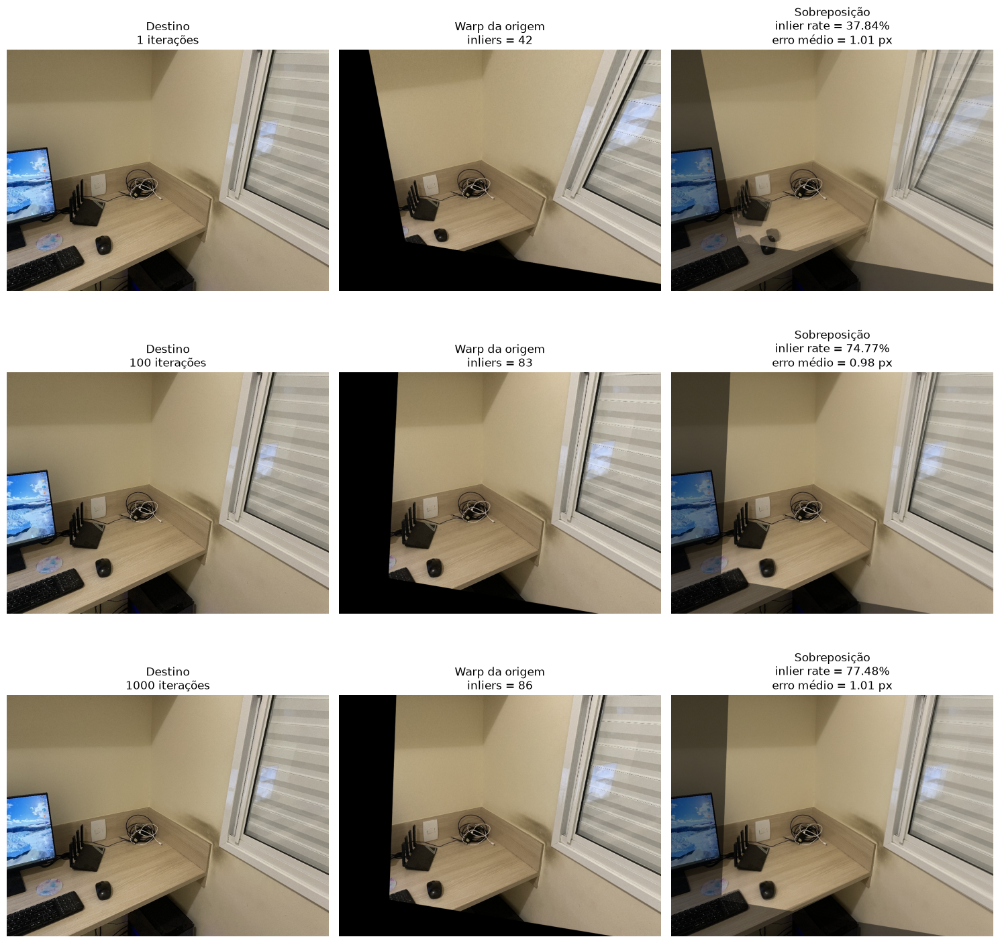

In [12]:
from src.visualization import plot_iterations

i = 0
j = 4

print(f"Par analisado: imagem {i} -> imagem {j}")
iteration_values = [1, 100, 1000]
results = []

for num_iterations in iteration_values:
    print(f"Iterações: {num_iterations}")
    H, pair_metrics = estimate_all_homographies(lowe_matrix, keypoints, [i, j], num_iterations=num_iterations)

    results.append({
        "iterations": num_iterations,
        "H": H[0],
        "metrics": pair_metrics[0]
    })

image_src = images[i]
image_dst = images[j]

plot_iterations(images[i], images[j], results)

# Etapa 6: Composição, blending, deghosting

A composição é realizada utilizando projeção cilíndrica. Para o blending, foi utilizado feathering para composição ingênua. A versão mais avançada de blending utiliza ajuste de exposição baseado em intensidade média de pixels, costura ótima para eliminação de fantasmas e feathering nas costuras.

In [13]:
from src.composition import cylindrical_stitching

warps, masks, info = cylindrical_stitching(images, order, homographies, 750)
print(info)

[Composition] Canvas: 1920 × 825
[Composition] Referência: imagem 2 (posição 3)
[Composition] Projetando imagem 3 (posição 0)
[Composition] Projetando imagem 7 (posição 1)
[Composition] Projetando imagem 6 (posição 2)
[Composition] Projetando imagem 2 (posição 3)
[Composition] Projetando imagem 5 (posição 4)
[Composition] Projetando imagem 4 (posição 5)
[Composition] Projetando imagem 0 (posição 6)
{'reference_position': 3, 'reference_index': 2, 'global_homographies': [array([[ 1.55147509e+00,  2.55976177e-01, -1.02173631e+03],
       [ 7.35743423e-02,  1.25360245e+00, -1.17546846e+01],
       [ 1.04474749e-03, -2.03375987e-04,  7.43265313e-01]]), array([[ 1.49306078e+00,  1.49478455e-01, -6.76511672e+02],
       [ 7.25565092e-02,  1.22398778e+00, -3.24666303e+01],
       [ 6.95351473e-04, -1.21613987e-04,  9.09936033e-01]]), array([[ 1.27674648e+00,  5.75454391e-02, -2.89612043e+02],
       [ 3.88264066e-02,  1.13646507e+00, -1.65683100e+01],
       [ 2.97784322e-04, -3.47074150e-05, 

[Blending] Feather blending com 7 imagens
[Blending]   Processando imagem 0
[Blending]   Processando imagem 1
[Blending]   Processando imagem 2
[Blending]   Processando imagem 3
[Blending]   Processando imagem 4
[Blending]   Processando imagem 5
[Blending]   Processando imagem 6


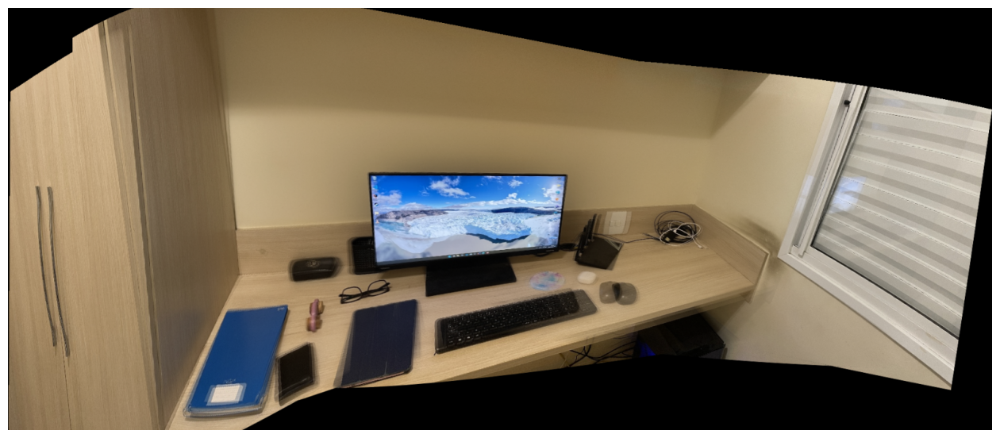

In [14]:
from src.blending import feather_blending, optimal_seam_blending
from src.visualization import plot_image

plot_image(feather_blending(warps, masks))

[Blending] Optimal seam com 7 imagens (feather=30)
[Blending]   Combinando panorama ← imagem 1


[Blending]   Combinando panorama ← imagem 2
[Blending]   Combinando panorama ← imagem 3
[Blending]   Combinando panorama ← imagem 4
[Blending]   Combinando panorama ← imagem 5
[Blending]   Combinando panorama ← imagem 6


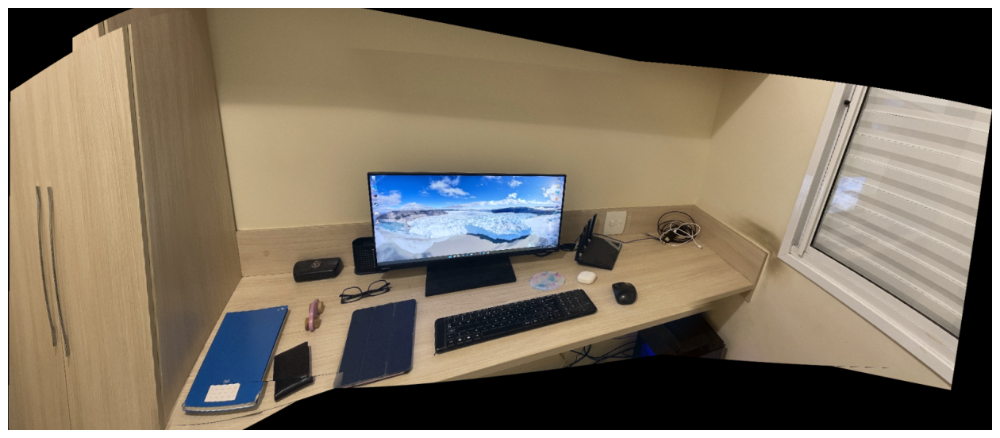

In [15]:
plot_image(optimal_seam_blending(warps, masks))